<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_11_KMeans_Clustering_Logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 11: K-Means Clustering – Logistics Dataset

## Objective
To apply K-Means clustering on logistics dataset to group delivery locations and determine optimal number of clusters using the Elbow Method.

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Load Dataset

In [ ]:
df = pd.read_csv("logistics_2000_dataset.csv")
df.head()

,latitude,longitude,distance_km,demand,accessibility
0,26.804834,80.864214,9.883383,42,0.091883
1,27.012257,80.858912,20.175776,21,0.047224
2,26.933518,81.096252,17.222248,37,0.054878
3,26.885517,80.859837,9.776628,27,0.092793
4,26.726167,80.867902,16.000369,29,0.058822


## Feature Selection

In [ ]:
X = df[["latitude", "longitude"]]

## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method (Finding Optimal K)

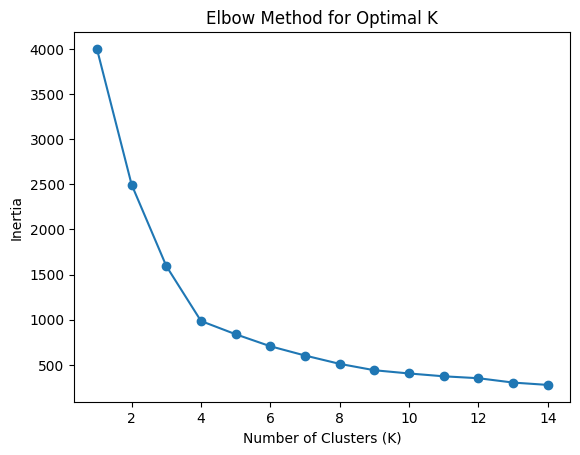

In [ ]:
inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

## Apply K-Means Clustering

In [ ]:
optimal_k = 4  # Choose based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

## Cluster Visualization

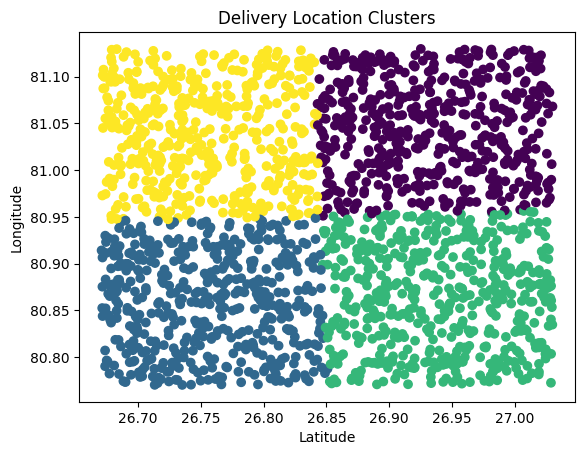

In [ ]:
plt.scatter(df["latitude"], df["longitude"], c=df["Cluster"])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Delivery Location Clusters")
plt.show()

## Cluster Summary Analysis

In [ ]:
summary = df.groupby("Cluster").agg({
    "latitude": "mean",
    "longitude": "mean",
    "demand": ["mean", "sum"],
    "distance_km": "mean",
    "accessibility": "mean"
})

print(summary)

          latitude  longitude     demand        distance_km accessibility
              mean       mean       mean    sum        mean          mean
Cluster                                                                  
0        26.934345  81.043623  25.105882  12804   14.334152      0.081214
1        26.755567  80.857398  24.896552  12274   15.005420      0.073825
2        26.940142  80.863848  24.873585  13183   14.287686      0.084085
3        26.753176  81.037722  25.321199  11825   14.823429      0.077572


## Conclusion

K-Means clustering successfully grouped delivery locations into optimal clusters. The elbow method helped determine the appropriate number of clusters, improving operational efficiency.